# 6. Pipeline de Random Forest

Se construye un modelo de Random Forest para estimar el salario mensual en quetzales, utilizando los mismos seis predictores y los mismos conjuntos de entrenamiento y validación que la actividad anterior (regresión lineal): los tres primeros trimestres de 2025 para entrenar y el cuarto trimestre para validar. El primer trimestre de 2026 se reserva para la evaluación final.

Se compara contra la regresión lineal ya entrenada y contra el modelo de referencia (media del salario de entrenamiento).

In [13]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Lab7_RandomForest")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Versión de Spark:", spark.version)

assert spark.version.startswith("3.5."), "El laboratorio requiere Spark 3.5.x."

Versión de Spark: 3.5.1


## Datos, predictores y conjuntos

Misma selección de columnas, mismos nombres y el mismo split por trimestre que en la regresión lineal, para que ambos modelos se comparen sobre exactamente los mismos registros.

In [14]:
PARQUET_DIR = "../working_dir/parquet"
MODELOS_DIR = "../working_dir/modelos"
RUTA_2025 = f"{PARQUET_DIR}/eneic_2025_preparado"

NUMERICAS = [
    "edad",
    "antiguedad",
    "horas_semanales"
]

CATEGORICAS = [
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio"
]

OBJETIVO = "salario_mensual"

COLUMNAS_MODELO = [
    "periodo_archivo",
    "NUM_HOGAR",
    "NUM_PERSONA",
    OBJETIVO,
    *NUMERICAS,
    *CATEGORICAS
]

df_2025_modelo = (
    spark.read.parquet(RUTA_2025)
    .select(*COLUMNAS_MODELO)
)

print(f"Registros preparados de 2025: {df_2025_modelo.count():,}")

Registros preparados de 2025: 53,025


In [15]:
train = (
    df_2025_modelo
    .filter(F.col("periodo_archivo").isin("2025T1", "2025T2", "2025T3"))
    .cache()
)

validacion = (
    df_2025_modelo
    .filter(F.col("periodo_archivo") == "2025T4")
    .cache()
)

n_train = train.count()
n_validacion = validacion.count()

assert n_train > 0, "El conjunto de entrenamiento está vacío."
assert n_validacion > 0, "El conjunto de validación está vacío."

print(f"Entrenamiento: {n_train:,} registros")
print(f"Validación:    {n_validacion:,} registros")

Entrenamiento: 40,361 registros
Validación:    12,664 registros


26/09/25 03:54:16 WARN CacheManager: Asked to cache already cached data.
26/09/25 03:54:16 WARN CacheManager: Asked to cache already cached data.


## Métricas y modelo de referencia

Se recalcula igual que en la regresión lineal, para tener el mismo punto de comparación en este notebook.

In [16]:
evaluadores = {
    "MAE": RegressionEvaluator(
        labelCol=OBJETIVO,
        predictionCol="prediction",
        metricName="mae"
    ),
    "RMSE": RegressionEvaluator(
        labelCol=OBJETIVO,
        predictionCol="prediction",
        metricName="rmse"
    ),
    "R2": RegressionEvaluator(
        labelCol=OBJETIVO,
        predictionCol="prediction",
        metricName="r2"
    )
}

def calcular_metricas(predicciones):
    return {
        nombre: evaluador.evaluate(predicciones)
        for nombre, evaluador in evaluadores.items()
    }

media_train = train.agg(
    F.avg(OBJETIVO).alias("media")
).first()["media"]

pred_referencia = validacion.withColumn(
    "prediction",
    F.lit(float(media_train))
)

metricas_referencia = calcular_metricas(pred_referencia)

print(f"Salario predicho por la referencia: Q{media_train:,.2f}")

display(
    pd.DataFrame([{
        "modelo": "Referencia: media de entrenamiento",
        **metricas_referencia
    }]).round(4)
)

Salario predicho por la referencia: Q3,383.12


,modelo,MAE,RMSE,R2
0,Referencia: media de entrenamiento,1672.5026,2889.5714,-0.0031


## Regresión lineal ya entrenada (actividad anterior)

Se cargan las métricas de validación del mejor modelo de regresión lineal, guardadas en el punto 5 (lr_resumen_validacion.json), para comparar directamente con el Random Forest.

In [17]:
with open(f"{MODELOS_DIR}/lr_resumen_validacion.json", "r", encoding="utf-8") as f:
    resumen_lr = json.load(f)

metricas_lr = resumen_lr["metricas_validacion_lr"]
nombre_lr = resumen_lr["configuracion"]["configuracion"]

print(f"Mejor LR: {nombre_lr}")
print(f"  MAE  = Q{metricas_lr['MAE']:,.2f}")
print(f"  RMSE = Q{metricas_lr['RMSE']:,.2f}")
print(f"  R²   = {metricas_lr['R2']:.4f}")

display(
    pd.DataFrame([{
        "modelo": f"Regresión lineal: {nombre_lr}",
        **metricas_lr
    }]).round(4)
)

Mejor LR: Sin regularización
  MAE  = Q1,210.14
  RMSE = Q2,186.42
  R²   = 0.4257


,modelo,MAE,RMSE,R2
0,Regresión lineal: Sin regularización,1210.1375,2186.4196,0.4257


## Función para construir el pipeline de Random Forest

StringIndexer y OneHotEncoder para las tres categóricas (mismo criterio de codificación que en la regresión lineal), VectorAssembler para combinarlas con los tres predictores numéricos, y RandomForestRegressor. No requiere estandarizar los predictores.

In [18]:
def crear_pipeline_rf(num_arboles, prof_max, semilla=42):
    indexadores = [
        StringIndexer(
            inputCol=columna,
            outputCol=f"{columna}_idx",
            handleInvalid="keep",
            stringOrderType="alphabetAsc"
        )
        for columna in CATEGORICAS
    ]

    codificador = OneHotEncoder(
        inputCols=[f"{columna}_idx" for columna in CATEGORICAS],
        outputCols=[f"{columna}_ohe" for columna in CATEGORICAS],
        dropLast=True
    )

    ensamblador = VectorAssembler(
        inputCols=NUMERICAS + [
            f"{columna}_ohe" for columna in CATEGORICAS
        ],
        outputCol="features",
        handleInvalid="error"
    )

    bosque = RandomForestRegressor(
        featuresCol="features",
        labelCol=OBJETIVO,
        predictionCol="prediction",
        numTrees=num_arboles,
        maxDepth=prof_max,
        seed=semilla
    )

    return Pipeline(
        stages=indexadores + [
            codificador,
            ensamblador,
            bosque
        ]
    )

## Configuraciones probadas

Se comparan tres configuraciones, variando cantidad de árboles y profundidad máxima, todas con la misma semilla (seed=42) y ajustadas exclusivamente con train:

| Configuración | numTrees | maxDepth |
|---|---:|---:|
| RF-A | 50 | 5 |
| RF-B | 100 | 10 |
| RF-C | 150 | 10 |

RF-C mantiene la misma profundidad que RF-B y solo aumenta la cantidad de árboles, para separar el efecto de cada hiperparámetro: cuánto ayuda sumar más árboles frente a cuánto ayuda dejarlos crecer más.

In [19]:
CONFIGURACIONES_RF = [
    {"configuracion": "RF-A", "numTrees": 50,  "maxDepth": 5},
    {"configuracion": "RF-B", "numTrees": 100, "maxDepth": 10},
    {"configuracion": "RF-C", "numTrees": 150, "maxDepth": 10},
]

modelos_rf = {}
filas_rf = []

for cfg in CONFIGURACIONES_RF:
    pipeline_rf = crear_pipeline_rf(cfg["numTrees"], cfg["maxDepth"])
    modelo = pipeline_rf.fit(train)
    pred_val = modelo.transform(validacion)
    metricas = calcular_metricas(pred_val)

    modelos_rf[cfg["configuracion"]] = modelo
    filas_rf.append({**cfg, **metricas})

    print(
        f"{cfg['configuracion']} (numTrees={cfg['numTrees']}, maxDepth={cfg['maxDepth']}): "
        f"MAE = Q{metricas['MAE']:,.2f} | RMSE = Q{metricas['RMSE']:,.2f} | R² = {metricas['R2']:.4f}"
    )

tabla_rf = pd.DataFrame(filas_rf)
display(tabla_rf.round(4))

RF-A (numTrees=50, maxDepth=5): MAE = Q1,157.22 | RMSE = Q2,162.22 | R² = 0.4383


26/09/25 03:55:25 WARN DAGScheduler: Broadcasting large task binary with size 1086.8 KiB
26/09/25 03:55:25 WARN DAGScheduler: Broadcasting large task binary with size 1927.1 KiB
26/09/25 03:55:26 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/09/25 03:55:27 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/09/25 03:55:28 WARN DAGScheduler: Broadcasting large task binary with size 1264.8 KiB
26/09/25 03:55:28 WARN DAGScheduler: Broadcasting large task binary with size 8.8 MiB
26/09/25 03:55:29 WARN DAGScheduler: Broadcasting large task binary with size 1858.4 KiB
                                                                                

RF-B (numTrees=100, maxDepth=10): MAE = Q1,076.06 | RMSE = Q1,985.95 | R² = 0.5262


26/09/25 03:55:31 WARN DAGScheduler: Broadcasting large task binary with size 1578.9 KiB
26/09/25 03:55:32 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/09/25 03:55:33 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
26/09/25 03:55:33 WARN DAGScheduler: Broadcasting large task binary with size 1191.0 KiB
26/09/25 03:55:34 WARN DAGScheduler: Broadcasting large task binary with size 8.1 MiB
26/09/25 03:55:35 WARN DAGScheduler: Broadcasting large task binary with size 1849.8 KiB
26/09/25 03:55:36 WARN DAGScheduler: Broadcasting large task binary with size 12.9 MiB
26/09/25 03:55:37 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
                                                                                

RF-C (numTrees=150, maxDepth=10): MAE = Q1,075.49 | RMSE = Q1,982.78 | R² = 0.5277


,configuracion,numTrees,maxDepth,MAE,RMSE,R2
0,RF-A,50,5,1157.2208,2162.2164,0.4383
1,RF-B,100,10,1076.0640,1985.9516,0.5262
2,RF-C,150,10,1075.4860,1982.7754,0.5277


## Selección de la mejor configuración

In [20]:
mejor_fila_rf = tabla_rf.loc[tabla_rf["RMSE"].idxmin()]
mejor_nombre_rf = mejor_fila_rf["configuracion"]
mejor_config_rf = {
    "configuracion": mejor_nombre_rf,
    "numTrees": int(mejor_fila_rf["numTrees"]),
    "maxDepth": int(mejor_fila_rf["maxDepth"])
}
metricas_mejor_rf = {
    "MAE": float(mejor_fila_rf["MAE"]),
    "RMSE": float(mejor_fila_rf["RMSE"]),
    "R2": float(mejor_fila_rf["R2"])
}
mejor_modelo_rf = modelos_rf[mejor_nombre_rf]

print(
    f"Configuración seleccionada: {mejor_nombre_rf} "
    f"(numTrees={mejor_config_rf['numTrees']}, maxDepth={mejor_config_rf['maxDepth']}), "
    "por tener el menor RMSE de validación."
)

Configuración seleccionada: RF-C (numTrees=150, maxDepth=10), por tener el menor RMSE de validación.


## Comparación entre entrenamiento y validación

Igual que se hizo con la regresión lineal, se revisa si hay brecha de sobreajuste: desempeño mucho mejor en entrenamiento que en validación.

In [21]:
pred_train_rf = mejor_modelo_rf.transform(train)
metricas_train_rf = calcular_metricas(pred_train_rf)

comparacion_ajuste_rf = pd.DataFrame([
    {
        "conjunto": "Entrenamiento",
        **metricas_train_rf
    },
    {
        "conjunto": "Validación",
        **metricas_mejor_rf
    }
])

display(comparacion_ajuste_rf.round(4))

,conjunto,MAE,RMSE,R2
0,Entrenamiento,1067.546,1928.9145,0.5595
1,Validación,1075.486,1982.7754,0.5277


### Análisis de sobreajuste

Si el RMSE (o el R²) de entrenamiento es notablemente mejor que el de validación, hay sobreajuste: el bosque está memorizando el ruido del conjunto de entrenamiento en vez de generalizar. Si son similares, como pasó con la regresión lineal, no hay evidencia de sobreajuste con esta configuración.

Es esperable que Random Forest con mayor profundidad presente más brecha que la regresión lineal, dado que los árboles profundos tienen mayor capacidad de memorizar patrones específicos del conjunto de entrenamiento.

## Comparación final: Referencia vs Regresión Lineal vs Random Forest

In [22]:
tabla_comparacion = pd.DataFrame([
    {"modelo": "Referencia: media de entrenamiento", **metricas_referencia},
    {"modelo": f"Regresión lineal: {nombre_lr}", **metricas_lr},
    {"modelo": f"Random Forest ({mejor_nombre_rf})", **metricas_mejor_rf},
])

tabla_comparacion["reduccion_RMSE_pct"] = (
    100 * (
        1
        - tabla_comparacion["RMSE"]
        / metricas_referencia["RMSE"]
    )
)

display(tabla_comparacion.round(4))

,modelo,MAE,RMSE,R2,reduccion_RMSE_pct
0,Referencia: media de entrenamiento,1672.5026,2889.5714,-0.0031,0.0000
1,Regresión lineal: Sin regularización,1210.1375,2186.4196,0.4257,24.3341
2,Random Forest (RF-C),1075.4860,1982.7754,0.5277,31.3817


## Importancia de las variables

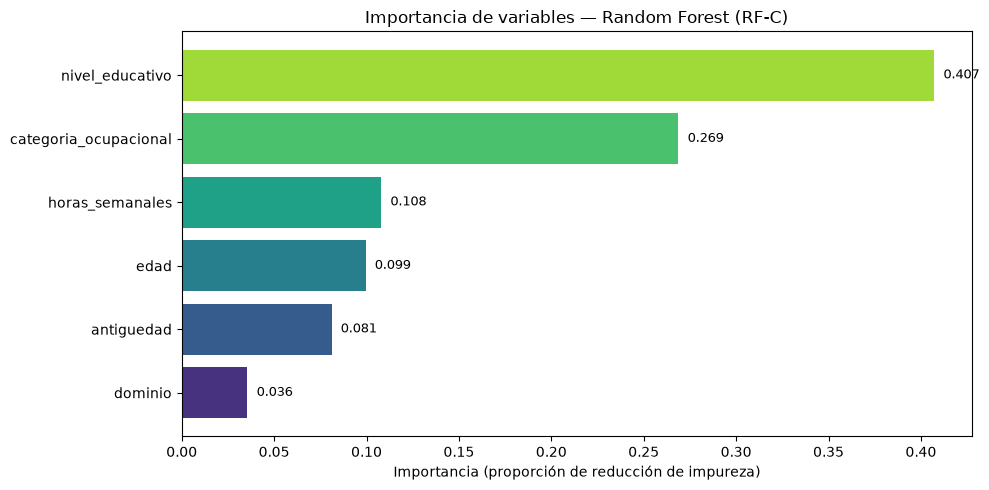

,variable,importancia
0,nivel_educativo,0.407190
1,categoria_ocupacional,0.268791
2,horas_semanales,0.107926
3,edad,0.099479
4,antiguedad,0.081051
5,dominio,0.035563


In [23]:
# Extraer el modelo RF del pipeline (último stage)
rf_model = mejor_modelo_rf.stages[-1]
importancias = rf_model.featureImportances.toArray()

# Las primeras posiciones son las numéricas
n_num = len(NUMERICAS)
imp_agrupada = {}
for i, var in enumerate(NUMERICAS):
    imp_agrupada[var] = importancias[i]

# Para las categóricas: determinar el tamaño de cada vector OHE
# a partir de un registro transformado
sample_transformed = mejor_modelo_rf.transform(train.limit(1))
sizes_ohe = []
for cat_var in CATEGORICAS:
    vec = sample_transformed.select(f"{cat_var}_ohe").first()[0]
    sizes_ohe.append(vec.size)

# Sumar las importancias de todas las columnas OHE de cada categórica
idx = n_num
for cat_var, size in zip(CATEGORICAS, sizes_ohe):
    imp_agrupada[cat_var] = sum(importancias[idx:idx + size])
    idx += size

# Ordenar y graficar
imp_df = (pd.DataFrame(
    list(imp_agrupada.items()),
    columns=["variable", "importancia"]
).sort_values("importancia", ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(imp_df["variable"], imp_df["importancia"],
               color=sns.color_palette("viridis", len(imp_df)))
ax.set_xlabel("Importancia (proporción de reducción de impureza)")
ax.set_title(f"Importancia de variables — Random Forest ({mejor_nombre_rf})")
for bar, val in zip(bars, imp_df["importancia"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

display(imp_df.sort_values("importancia", ascending=False).reset_index(drop=True))

## Interpretación

### Comparación final

| Modelo | MAE | RMSE | R² | Reducción de RMSE vs. referencia |
|---|---:|---:|---:|---:|
| Referencia: media de entrenamiento | Q1,672.50 | Q2,889.57 | -0.0031 | — |
| Regresión lineal (sin regularización) | Q1,210.14 | Q2,186.42 | 0.4257 | 24.33% |
| Random Forest (RF-C) | Q1,075.49 | Q1,982.78 | 0.5277 | 31.38% |

### Comparación de configuraciones de Random Forest

Se probaron tres configuraciones variando el número de árboles (50, 100, 150) y la profundidad máxima (5, 10, 10). Pasar de RF-A a RF-B (más árboles y más profundidad) bajó el RMSE de validación de Q2,162.22 a Q1,985.95, una mejora considerable. Pasar de RF-B a RF-C (mismos 10 de profundidad, 50 árboles más) solo lo bajó a Q1,982.78, una mejora marginal. Esto sugiere que la profundidad máxima influyó más que la cantidad de árboles en este problema, y que ya se está cerca del límite de lo que estos seis predictores pueden explicar.

La configuración seleccionada fue **RF-C (numTrees=150, maxDepth=10)**, por tener el menor RMSE de validación.

### Comparación RF vs. Regresión lineal

Random Forest obtuvo mejores resultados que la regresión lineal. El RMSE de validación bajó de Q2,186.42 (regresión lineal) a Q1,982.78 (Random Forest), y el R² subió de 0.4257 a 0.5277. En términos de reducción de error frente al modelo de referencia, la regresión lineal redujo el RMSE en 24.33% y el Random Forest en 31.38%.

La diferencia probablemente se explica porque Random Forest puede capturar relaciones no lineales e interacciones entre los predictores sin que haya que especificarlas a mano, por ejemplo, que el efecto de las horas trabajadas sobre el salario cambie según la categoría ocupacional. La regresión lineal, en cambio, solo puede sumar el efecto de cada predictor de forma aditiva.

### ¿Hay sobreajuste?

Para RF-C, el RMSE en entrenamiento fue Q1,928.91 (R² = 0.5595) y en validación Q1,982.78 (R² = 0.5277). La brecha es pequeña, así que no hay evidencia fuerte de sobreajuste con esta configuración: el modelo generaliza de forma parecida a como se ajustó, similar a lo que ya se había observado con la regresión lineal.

### Importancia de variables

nivel_educativo (40.7%) y categoria_ocupacional (26.9%) concentran casi el 68% de la importancia total del modelo, muy por encima de las tres variables numéricas juntas (horas_semanales 10.8%, edad 9.9%, antiguedad 8.1%, que suman 28.8%) y de dominio (3.6%), la menos relevante. Esto indica que, dentro de este modelo, el salario está mucho más asociado al nivel educativo y al tipo de puesto que a cuántas horas trabaja la persona o a su edad y antigüedad — un análisis complementario que la regresión lineal no ofrece directamente.


## Guardar el mejor pipeline

In [24]:
os.makedirs(MODELOS_DIR, exist_ok=True)

RUTA_MODELO_RF = f"{MODELOS_DIR}/rf_mejor_validacion"

mejor_modelo_rf.write().overwrite().save(RUTA_MODELO_RF)

resumen_rf = {
    "configuracion": mejor_config_rf,
    "periodos_entrenamiento": ["2025T1", "2025T2", "2025T3"],
    "periodo_validacion": "2025T4",
    "predictores_numericos": NUMERICAS,
    "predictores_categoricos": CATEGORICAS,
    "objetivo": OBJETIVO,
    "seed": 42,
    "media_entrenamiento": float(media_train),
    "metricas_validacion_rf": metricas_mejor_rf,
    "metricas_validacion_lr": {k: float(v) for k, v in metricas_lr.items()},
    "metricas_validacion_referencia": {k: float(v) for k, v in metricas_referencia.items()},
    "version_spark": spark.version
}

with open(
    f"{MODELOS_DIR}/rf_resumen_validacion.json",
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(resumen_rf, archivo, ensure_ascii=False, indent=2)

tabla_rf.to_csv(
    f"{MODELOS_DIR}/rf_configuraciones_validacion.csv",
    index=False
)

print("Pipeline guardado en:", RUTA_MODELO_RF)
print("Configuración y métricas guardadas.")

26/09/25 03:58:09 WARN TaskSetManager: Stage 331 contains a task of very large size (1086 KiB). The maximum recommended task size is 1000 KiB.


Pipeline guardado en: ../working_dir/modelos/rf_mejor_validacion
Configuración y métricas guardadas.
